In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("house_price_dataset.csv")

df.head()

,square_feet,bedrooms,bathrooms,floors,house_age,garage_spaces,distance_city_center,school_rating,crime_rate,property_tax,parks_nearby,shopping_malls_nearby,public_transport_score,lot_size,neighborhood_quality,price
0,1460,5,3,1,13,2,17.070922,6.300493,4.458496,5549,2,3,3.224339,2946,9.301582,223600.230307
1,4372,5,2,2,24,2,17.206385,2.252690,3.465780,5841,0,0,9.139644,4415,7.381780,563619.352945
2,3692,4,2,2,14,1,21.503904,1.030491,8.359241,5041,4,1,9.185240,2394,8.067408,436197.080579
3,1066,3,1,1,5,1,6.146973,3.207611,7.584460,6999,4,2,4.908338,3421,1.765292,84727.953386
4,4044,3,3,2,28,2,8.314471,7.341274,3.212552,6024,2,1,1.849476,4919,6.244886,605726.608809


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   square_feet             2000 non-null   int64  
 1   bedrooms                2000 non-null   int64  
 2   bathrooms               2000 non-null   int64  
 3   floors                  2000 non-null   int64  
 4   house_age               2000 non-null   int64  
 5   garage_spaces           2000 non-null   int64  
 6   distance_city_center    2000 non-null   float64
 7   school_rating           2000 non-null   float64
 8   crime_rate              2000 non-null   float64
 9   property_tax            2000 non-null   int64  
 10  parks_nearby            2000 non-null   int64  
 11  shopping_malls_nearby   2000 non-null   int64  
 12  public_transport_score  2000 non-null   float64
 13  lot_size                2000 non-null   int64  
 14  neighborhood_quality    2000 non-null   

In [5]:
df.describe()

,square_feet,bedrooms,bathrooms,floors,house_age,garage_spaces,distance_city_center,school_rating,crime_rate,property_tax,parks_nearby,shopping_malls_nearby,public_transport_score,lot_size,neighborhood_quality,price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2825.736500,3.021000,2.029000,1.507500,19.468500,0.983500,15.480872,5.506101,4.986418,4482.984000,1.975000,1.494000,5.510189,5503.533500,5.614996,369260.180538
std,1258.916222,1.421115,0.815163,0.500069,11.387311,0.836408,8.218929,2.623603,2.928288,2028.778221,1.389367,1.147442,2.600451,2587.575807,2.590150,157060.292622
min,601.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.001532,1.001420,0.013336,1000.000000,0.000000,0.000000,1.000084,1002.000000,1.004590,22471.149991
25%,1720.000000,2.000000,1.000000,1.000000,10.000000,0.000000,8.496623,3.216616,2.387218,2695.000000,1.000000,0.000000,3.263522,3297.750000,3.377439,235968.888319
50%,2835.500000,3.000000,2.000000,2.000000,19.000000,1.000000,15.525843,5.419940,4.902855,4494.500000,2.000000,1.000000,5.500626,5478.500000,5.632417,372827.490286
75%,3902.000000,4.000000,3.000000,2.000000,29.000000,2.000000,22.439485,7.827173,7.620201,6225.750000,3.000000,3.000000,7.756804,7783.000000,7.846128,499610.795758
max,4999.000000,5.000000,3.000000,2.000000,39.000000,2.000000,29.985651,9.997059,9.988448,7998.000000,4.000000,3.000000,9.995344,9996.000000,9.989136,710673.095696


In [6]:
df.isnull().sum()

square_feet               0
bedrooms                  0
bathrooms                 0
floors                    0
house_age                 0
garage_spaces             0
distance_city_center      0
school_rating             0
crime_rate                0
property_tax              0
parks_nearby              0
shopping_malls_nearby     0
public_transport_score    0
lot_size                  0
neighborhood_quality      0
price                     0
dtype: int64

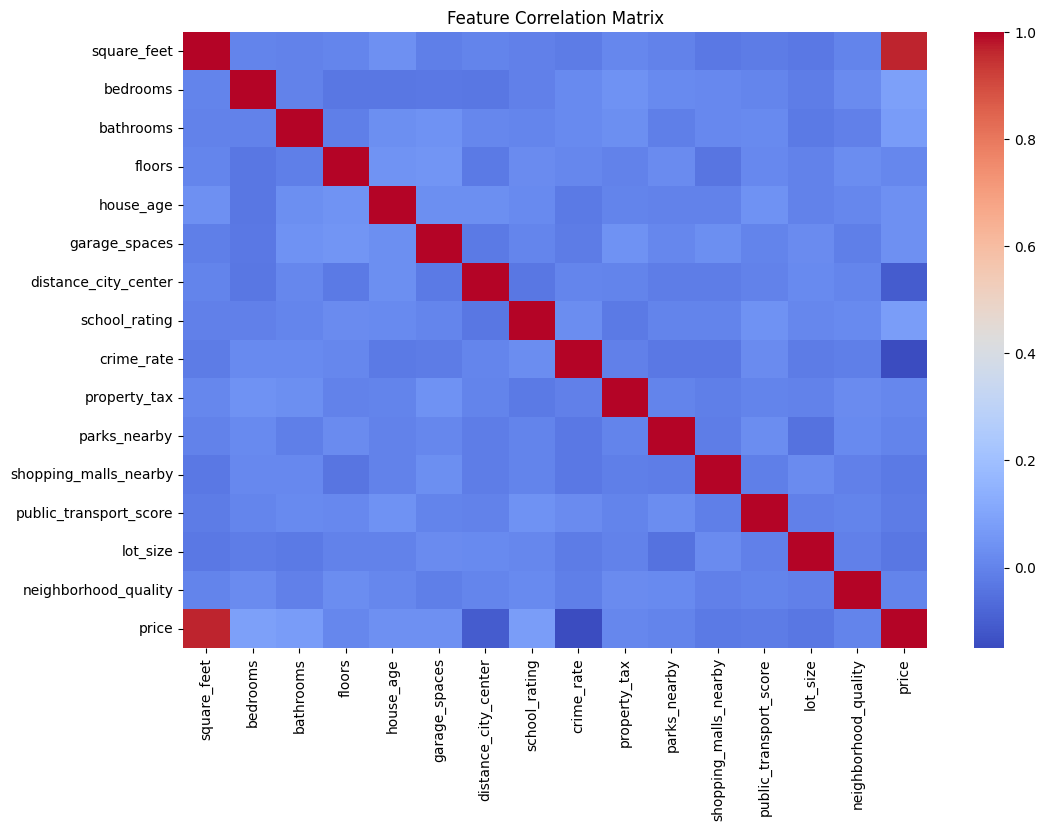

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

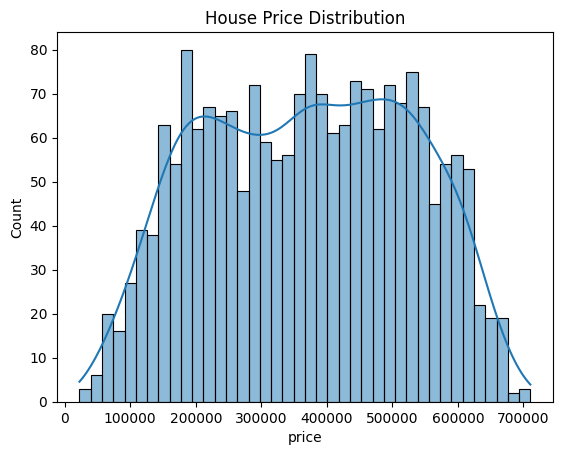

In [8]:
sns.histplot(df["price"], bins=40, kde=True)
plt.title("House Price Distribution")
plt.show()

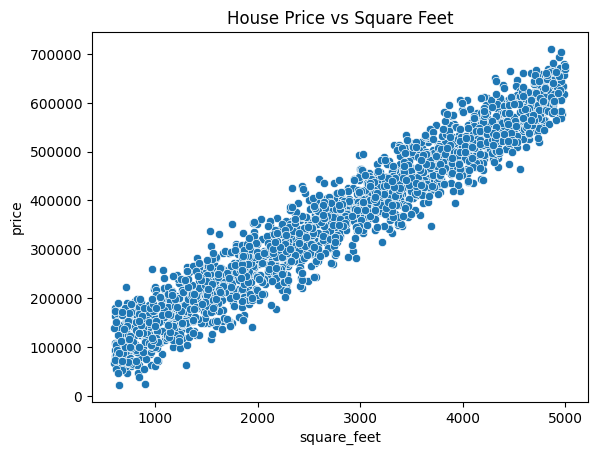

In [9]:
sns.scatterplot(x="square_feet", y="price", data=df)
plt.title("House Price vs Square Feet")
plt.show()

In [10]:
from scipy import stats

z_scores = np.abs(stats.zscore(df))

df = df[(z_scores < 3).all(axis=1)]

df.shape

(2000, 16)

In [11]:
X = df.drop("price", axis=1)
y = df["price"]

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)
print("RMSE:", rmse)

R2 Score: 0.982328893421242
Mean Absolute Error: 16100.097322636428
RMSE: 20641.86249364186


C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [17]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.9824017  0.98258174 0.98283621 0.98372438 0.98411664]
Average CV Score: 0.983132133497514


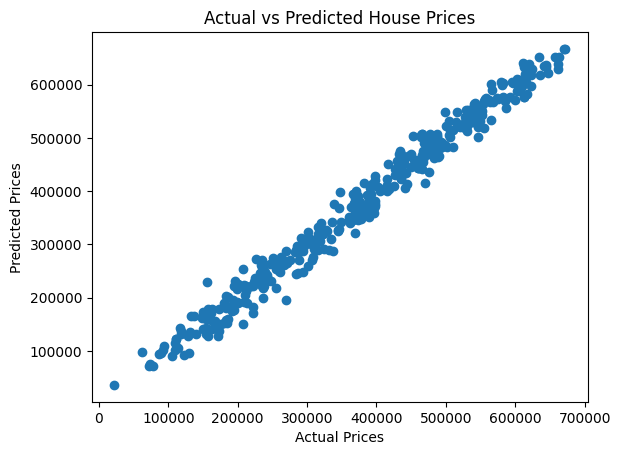

In [18]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

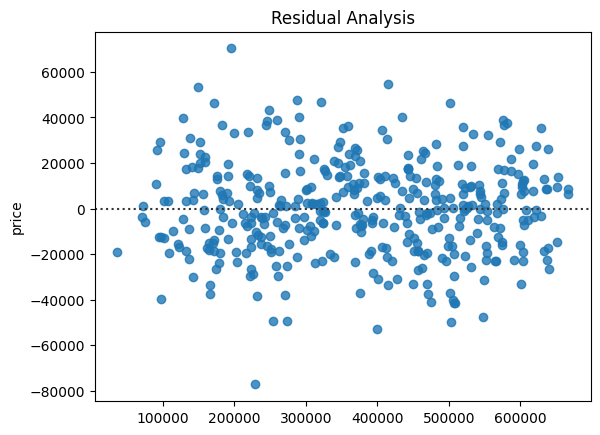

In [19]:
sns.residplot(x=y_pred, y=y_test - y_pred)
plt.title("Residual Analysis")
plt.show()